<a href="https://colab.research.google.com/github/miaalvaradoc/IA-TEAM-ASSIGNMENTS/blob/main/ASSIGNMENTS/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project.- Training a Machine Learning model on medical images**
*Class Hour: 2:30 - 5:00 p.m. (LMMJV)*

* Mia Alvarado Cruz - 2114905
* María Fernanda Soriano Lara - 2177962
* Ana Lucía Vasquez Andrade - 2095379
* Alani Monserrath Molina Rosas - 2114717

# **Load libraries**

In the next cell, the necessary libraries are imported.
* tensorflow for building and training the neural network
* kagglehub to download the dataset from kaggle
* numpy for numerical operations
* pandas to process and organizing the dataset
* os to create paths and access folders
* cv2 to read, process and transform images
* matplotlib.pyplot for plotting and visualization
* urllib.request to download data from internet using url


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models
import kagglehub
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import urllib.request
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# **Load data**
Here we used th same code as in class to import the datasets that we needed in this assignment. Obtaining the Skin Cancer MNIST: HAM10000 database from Kaggle

In [ ]:
# 1. Set the Kaggle API token
os.environ['KAGGLE_API_TOKEN'] = "KGAT_98246e427829ab90e4cea3779473ad96"

# 2. Install the Kaggle API
!pip install kaggle -q

# 3. Download the HAM10000 dataset from Kaggle
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

# 4. Extract the downloaded dataset
print("Extracting the HAM10000 dataset...")
!unzip -qo skin-cancer-mnist-ham10000.zip
print("Dataset successfully extracted!")


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [05:03<00:00, 18.4MB/s]

Descomprimiendo imágenes médicas...
¡Descarga completada con éxito!


Here we are showing an example of an image, in order to visualize what we have in the database.

Mostrando: ISIC_0025422.jpg
Resolución Original: 600 x 450 píxeles



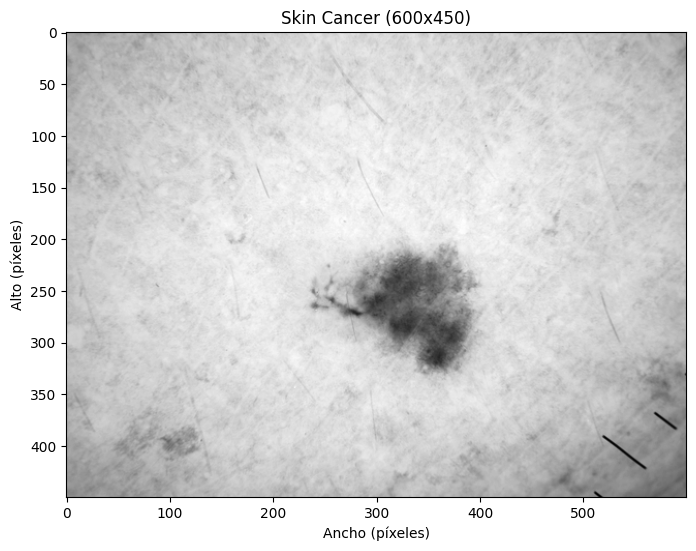

In [ ]:
# 1. Define the folder containing the dermoscopic images
carpeta_SC = 'HAM10000_images_part_1'

# 2. Retrieve the list of image files
imagenes = [f for f in os.listdir(carpeta_SC) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]

# 3. Select the first image from the dataset

nombre_archivo = imagenes[0]
ruta_completa = os.path.join(carpeta_SC, nombre_archivo)

# 4. Read the image in grayscale
img_original = cv2.imread(ruta_completa, cv2.IMREAD_GRAYSCALE)

# 5. Display the image and its original resolution

alto, ancho = img_original.shape
print(f"Mostrando: {nombre_archivo}")
print(f"Resolución Original: {ancho} x {alto} píxeles\n")

plt.figure(figsize=(8, 8))
plt.imshow(img_original, cmap='gray')
plt.title(f"Skin Cancer ({ancho}x{alto})")
plt.xlabel("Ancho (píxeles)")
plt.ylabel("Alto (píxeles)")
plt.grid(False)
plt.show()

# **Data Preprocessing**

At this stage, preprocessing of the images within the database is carried out.

First, we examine the resolution of the images to ascertain whether there are different resolutions within the database.

In [ ]:
# Check the resolution of the images
from collections import Counter

contador = Counter()

carpeta = "HAM10000_images_part_1"

for archivo in os.listdir(carpeta):

    ruta = os.path.join(carpeta, archivo)

    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        alto, ancho = img.shape
        contador[(ancho, alto)] += 1
print(contador)

Counter({(600, 450): 5000})


Next, two separate lists are created: one to store the images from the database and another to store the labels for each image.

In [ ]:
# Load the metadata file
metadata = pd.read_csv("HAM10000_metadata.csv")


# Create lists to store the images and their labels
imagenes = []
labels = []


# Encode each lesion category as a numerical label
clases = {"akiec": 0,"bcc": 1,"bkl": 2,"df": 3,"mel": 4,"nv": 5,"vasc": 6}


# Define the complete class names
class_names = [ "Actinic keratoses","Basal cell carcinoma","Benign keratosis","Dermatofibroma","Melanoma","Melanocytic nevus","Vascular lesion"]


# Define the folders containing the dataset images
carpeta_1 = "HAM10000_images_part_1"
carpeta_2 = "HAM10000_images_part_2"


# Load each image and assign its corresponding label
for i in range(len(metadata)):

    nombre_archivo = metadata.loc[i, "image_id"] + ".jpg"
    clase = metadata.loc[i, "dx"]

    ruta_1 = os.path.join(carpeta_1, nombre_archivo)
    ruta_2 = os.path.join(carpeta_2, nombre_archivo)

    if os.path.exists(ruta_1):
        ruta = ruta_1
    else:
        ruta = ruta_2

    imagen = cv2.imread(ruta)

    if imagen is not None:

        # Convert the image from BGR to RGB
        imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

        # Resize the image to 128 × 128 pixels
        imagen = cv2.resize(imagen, (128, 128))

        # Store the processed image and its label
        imagenes.append(imagen)
        labels.append(clases[clase])

The presence of null values is now checked, and if any are found, they are replaced with the mean value.

In [ ]:
# Check for missing values and replace them with the median age
mediana = metadata.age.median()
metadata.age = metadata.age.fillna(mediana)
print(f"Reemplazamos los valores nulos por la mediana de valor: {mediana}")
val_null = metadata.isnull().sum()
print(f"Verificando si existen valores nulos:\n{val_null}")

Reemplazamos los valores nulos por la mediana de valor: 50.0
Verificando si existen valores nulos:
lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64


The images within the database are normalized.

In [ ]:
# Convert the image and label lists into NumPy arrays
X = np.array(imagenes)
y = np.array(labels)


# Normalize the pixel values to the range [0, 1]
X = X.astype("float32") / 255.0


The total data is divided between test and train, with an 80-20 ratio

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Show 10 images of the training data

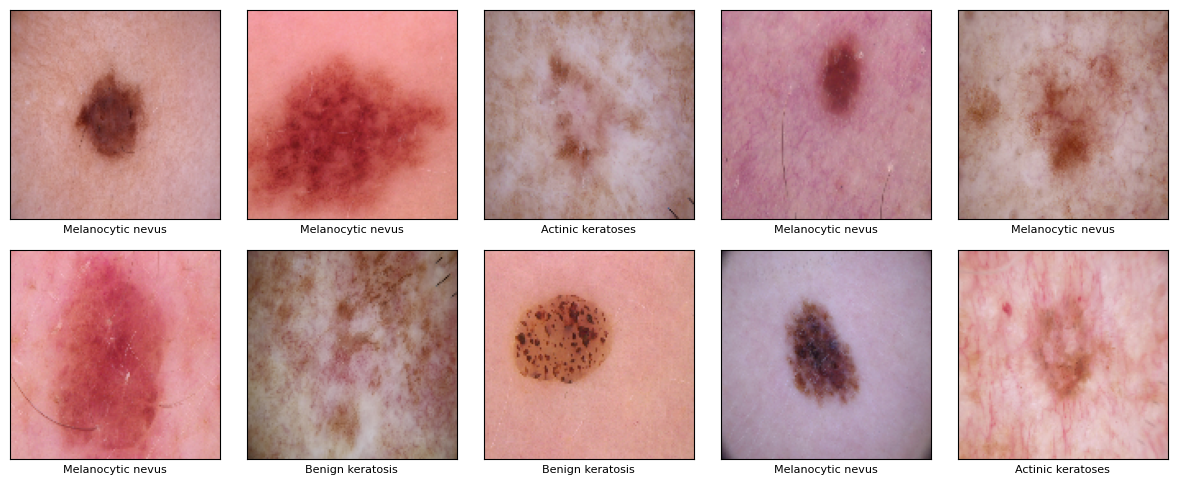

In [ ]:
# Display 10 sample images from the training dataset
plt.figure(figsize=(12, 12))

for i in range(10):

    plt.subplot(5, 5, i + 1)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(X_train[i])

    plt.xlabel(
        class_names[y_train[i]],
        fontsize=8
    )

plt.tight_layout()
plt.show()

# **Structure and training of Convolutional Artificial Neural Network**

The architecture of the CNN model is established, including the convolutional and pooling layers, as well as the dense layers.

In [ ]:
model = models.Sequential([
    layers.Input(shape=(128, 128,3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),


    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [ ]:
# Display the CNN architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Chosse the model and perfornm 15 epochs

In [ ]:
# Compile the CNN model by defining the optimizer,
# loss function, and evaluation metric
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train the CNN model using the training dataset
# and validate its performance with the testing dataset
history = model.fit(X_train, y_train,
                    epochs=15,
                    validation_data=(X_test, y_test))

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


251/251 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.6656 - loss: 1.0446 - val_accuracy: 0.6695 - val_loss: 0.9188
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6671 - loss: 0.9217 - val_accuracy: 0.6825 - val_loss: 0.8649
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6777 - loss: 0.8591 - val_accuracy: 0.6760 - val_loss: 0.8381
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6868 - loss: 0.8341 - val_accuracy: 0.7089 - val_loss: 0.8360
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6991 - loss: 0.8095 - val_accuracy: 0.7134 - val_loss: 0.7550
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7138 - loss: 0.7702 - val_accuracy: 0.7134 - val_loss: 0.7776
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7315 - loss: 0.7319 - val_accuracy: 0.7244 - val_loss: 0.7755
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7225 - loss: 0.7211 - val_accuracy: 0.73

# **CNN Acuracy results**
Check the test accuracy and test loss

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7544 - loss: 0.7276
Test accuracy: 0.7544
Test loss: 0.7276


In [ ]:
# Generate predictions for the testing dataset
probabilidades = model.predict(X_test)

# Obtain the predicted class with the highest probability
predicciones = np.argmax(probabilidades, axis=1)

# Display the classification report
print(
    classification_report(
        y_test,
        predicciones,
        target_names=class_names,
        zero_division=0
    )
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
                      precision    recall  f1-score   support

   Actinic keratoses       0.57      0.18      0.28        65
Basal cell carcinoma       0.49      0.56      0.52       103
    Benign keratosis       0.53      0.36      0.43       220
      Dermatofibroma       0.00      0.00      0.00        23
            Melanoma       0.51      0.26      0.34       223
   Melanocytic nevus       0.82      0.96      0.88      1341
     Vascular lesion       0.71      0.54      0.61        28

            accuracy                           0.75      2003
           macro avg       0.52      0.41      0.44      2003
        weighted avg       0.71      0.75      0.72      2003



# **Training Performance Visualization**

Show a grafic with the accuracy and val accuracy

63/63 - 1s - 11ms/step - accuracy: 0.7544 - loss: 0.7276


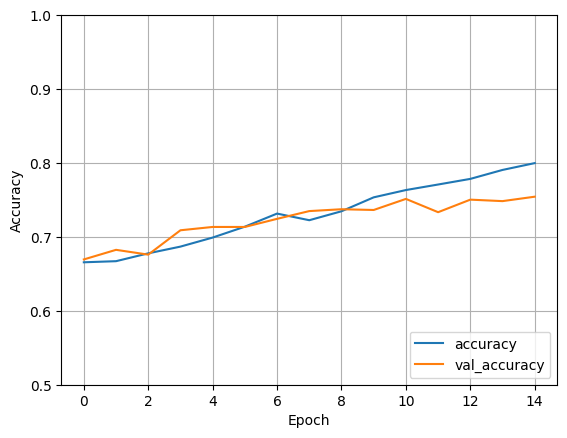

In [ ]:
# Plot the training and validation accuracy
# over the training epochs

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.grid(True)


# Evaluate the model once again
test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

# **Predictions with the train CNN**
Check 10 predictions and the result

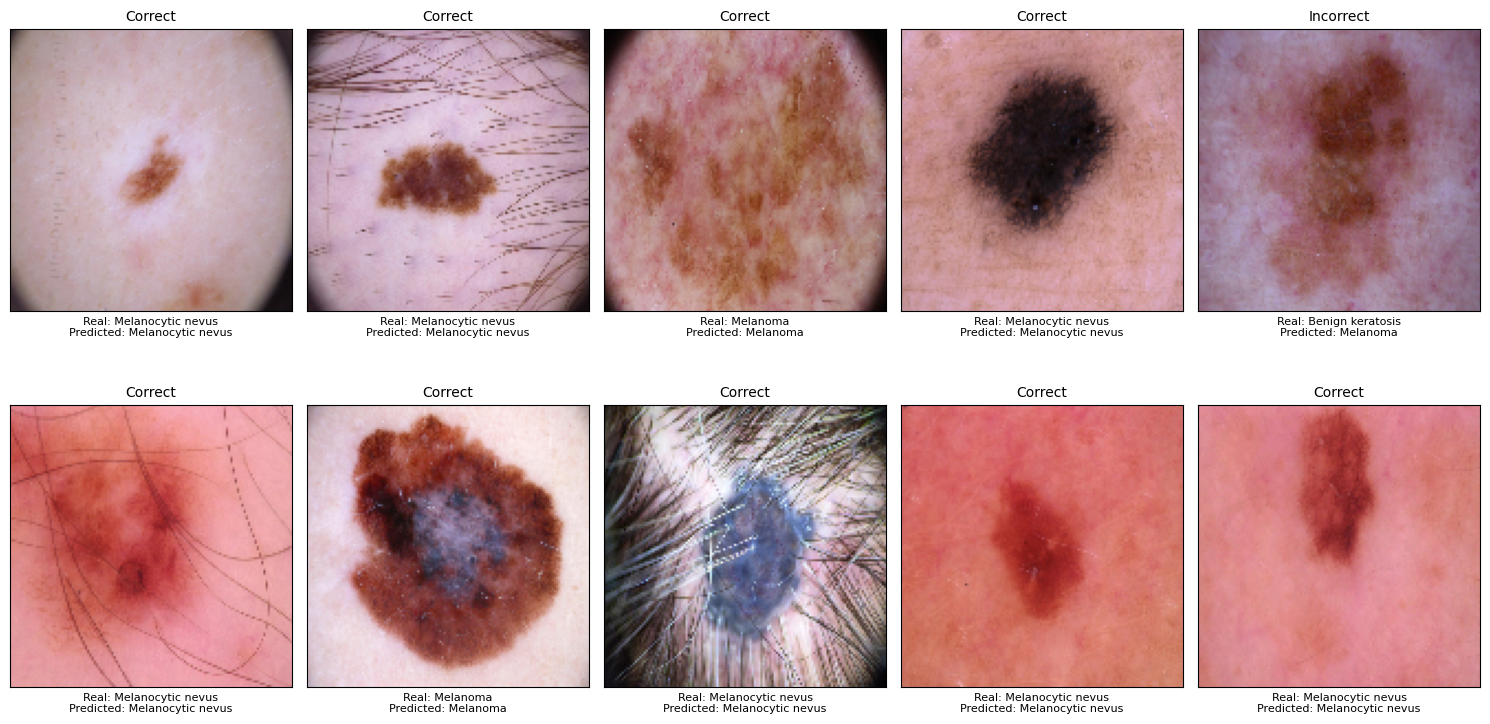

In [ ]:
# Display 10 sample predictions and compare
# the predicted labels with the true labels
plt.figure(figsize=(15, 8))

for i in range(10):

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    clase_real = class_names[y_test[i]]
    clase_predicha = class_names[predicciones[i]]

    if y_test[i] == predicciones[i]:
        resultado = "Correct"
    else:
        resultado = "Incorrect"

    plt.title(resultado, fontsize=10)

    plt.xlabel(
        f"Real: {clase_real}\nPredicted: {clase_predicha}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

Finally, the distribution of the images according to each label within the database was reviewed, with the aim of determining whether it was biased.

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


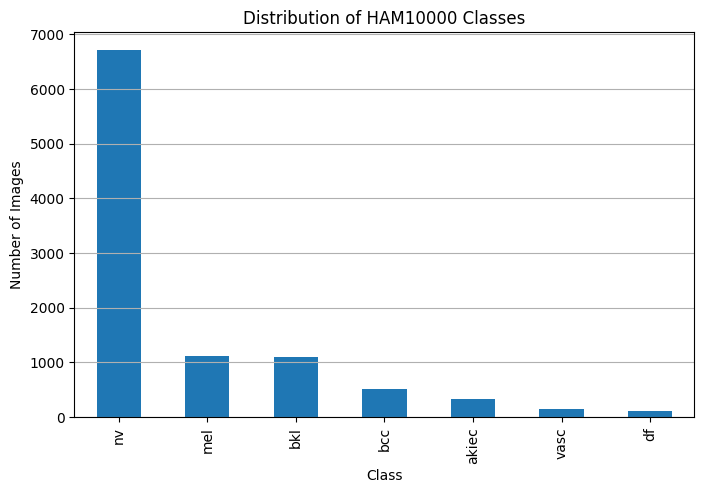

In [ ]:
# Count the number of images in each lesion category
conteo = metadata["dx"].value_counts()

print(conteo)

# Plot the distribution of the lesion categories
plt.figure(figsize=(8,5))
conteo.plot(kind="bar")

plt.title("Distribution of HAM10000 Classes")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y")
plt.show()

In [ ]:
# Display the class distribution for the
# training and testing datasets
print(pd.Series(y_train).value_counts().sort_index())
print()
print(pd.Series(y_test).value_counts().sort_index())

0     262
1     411
2     879
3      92
4     890
5    5364
6     114
Name: count, dtype: int64

0      65
1     103
2     220
3      23
4     223
5    1341
6      28
Name: count, dtype: int64
